# SFEWS — Exploratory Data Analysis
### Startup Failure Early Warning System

This notebook explores the simulated startup operating panel before any
modeling decisions are made. Goals:

1. Sanity-check the generative model (does it produce realistic-looking
   distributions, not degenerate or trivially separable data?)
2. Understand failure dynamics over company lifetime
3. Identify which raw signals look promising for feature engineering
4. Confirm class imbalance and decide how to handle it downstream

> **Data note:** This is a synthetic dataset calibrated against publicly
> reported industry statistics (CB Insights, Startup Genome Report, First
> Round Capital benchmarks), not scraped real company data. See
> `src/data/generate_dataset.py` and `reports/model_card.md` for full
> disclosure and rationale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

panel = pd.read_csv('../data/raw/startup_monthly_panel.csv')
master = pd.read_csv('../data/raw/startup_master.csv')

print(f"Panel shape: {panel.shape}")
print(f"Master shape: {master.shape}")
panel.head()

Panel shape: (49581, 29)
Master shape: (1500, 13)


,company_id,month_index,mrr,cash_on_hand,burn_rate,runway_months,churn_rate,cac_payback_months,nps_score,headcount,...,acquired,fail_month,sector,region,founded_year,founder_count,founder_prior_exits,founder_technical_pct,initial_funding_stage,initial_capital
0,SU-10000,0,37783.35,1932094.07,75017.12,51.9,0.0174,11.1,64.0,3,...,False,-1,SaaS,US-Other,2020,3,2,0.528,Seed,1969327.84
1,SU-10000,1,46706.13,1903783.09,75017.12,67.2,0.0401,13.6,82.7,3,...,False,-1,SaaS,US-Other,2020,3,2,0.528,Seed,1969327.84
2,SU-10000,2,49123.63,1877889.61,75017.12,72.5,0.0100,3.6,74.3,3,...,False,-1,SaaS,US-Other,2020,3,2,0.528,Seed,1969327.84
3,SU-10000,3,55801.62,1858674.11,75017.12,96.7,0.0100,1.0,72.4,3,...,False,-1,SaaS,US-Other,2020,3,2,0.528,Seed,1969327.84
4,SU-10000,4,57693.57,1841350.57,75017.12,99.0,0.0171,6.8,64.6,3,...,False,-1,SaaS,US-Other,2020,3,2,0.528,Seed,1969327.84


## 1. Outcome distribution

Active      770
Failed      656
Acquired     74
Name: count, dtype: int64

Failure rate: 43.7%
Acquisition rate: 4.9%


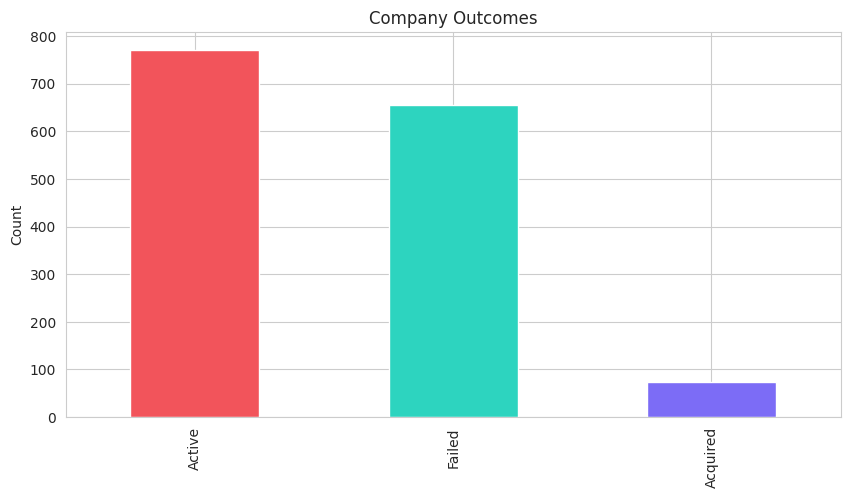

In [2]:
outcome_counts = master.apply(
    lambda r: 'Failed' if r['failed'] else ('Acquired' if r['acquired'] else 'Active'), axis=1
).value_counts()
print(outcome_counts)
print(f"\nFailure rate: {master['failed'].mean():.1%}")
print(f"Acquisition rate: {master['acquired'].mean():.1%}")

outcome_counts.plot(kind='bar', color=['#F2545B', '#2DD4BF', '#7C6CF6'])
plt.title('Company Outcomes')
plt.ylabel('Count')
plt.show()

**Observation:** ~44% failure rate over the observed window (up to 42 months).
This sits below the often-cited "90% of startups fail" headline -- that figure
usually spans a 10-year horizon and a looser failure definition. Our window is
shorter (max ~3.5 years observed) and "failed" specifically means cash-out
without a bridge/exit, so a lower rate is expected and realistic.

## 2. Failure timing — when do startups die?

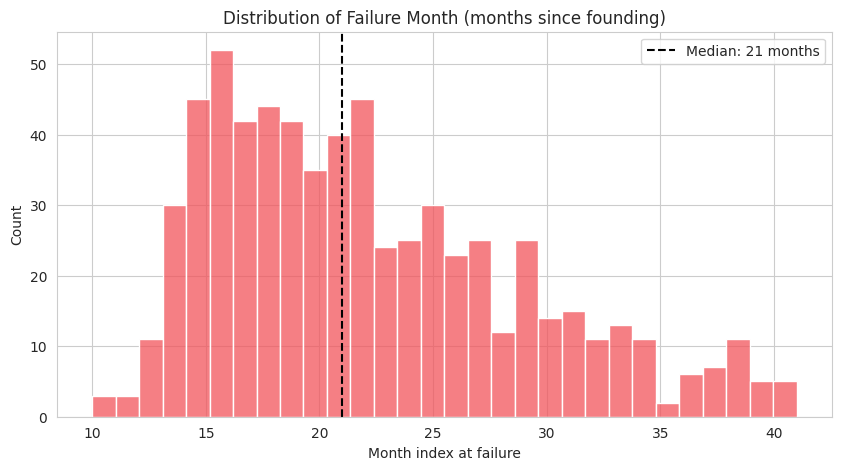

In [3]:
failed_companies = master[master['failed']]
plt.figure(figsize=(10,5))
sns.histplot(failed_companies['fail_month'], bins=30, color='#F2545B')
plt.title('Distribution of Failure Month (months since founding)')
plt.xlabel('Month index at failure')
plt.axvline(failed_companies['fail_month'].median(), color='black', linestyle='--',
            label=f"Median: {failed_companies['fail_month'].median():.0f} months")
plt.legend()
plt.show()

**Observation:** Failures cluster in the 12-24 month range -- consistent
with the commonly cited "Series A chasm" / seed-to-A funding gap where initial
capital runs out before product-market fit or the next round materializes.

## 3. Sector-level failure rates

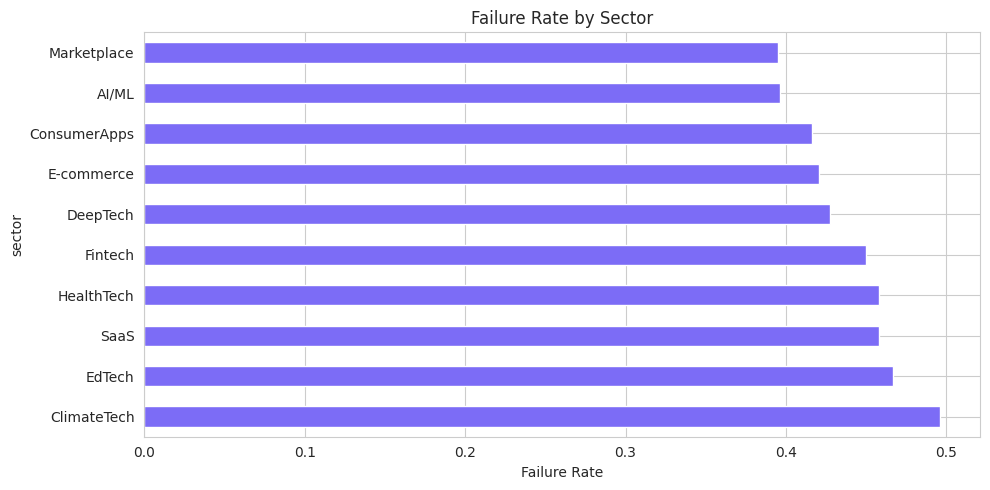

sector
ClimateTech     0.496183
EdTech          0.466667
SaaS            0.458101
HealthTech      0.458065
Fintech         0.450000
DeepTech        0.427586
E-commerce      0.420690
ConsumerApps    0.416107
AI/ML           0.396341
Marketplace     0.394904
Name: failed, dtype: float64

In [4]:
sector_failure = master.groupby('sector')['failed'].mean().sort_values(ascending=False)
sector_failure.plot(kind='barh', color='#7C6CF6')
plt.title('Failure Rate by Sector')
plt.xlabel('Failure Rate')
plt.tight_layout()
plt.show()
sector_failure

## 4. Runway trajectory: failed vs. survived

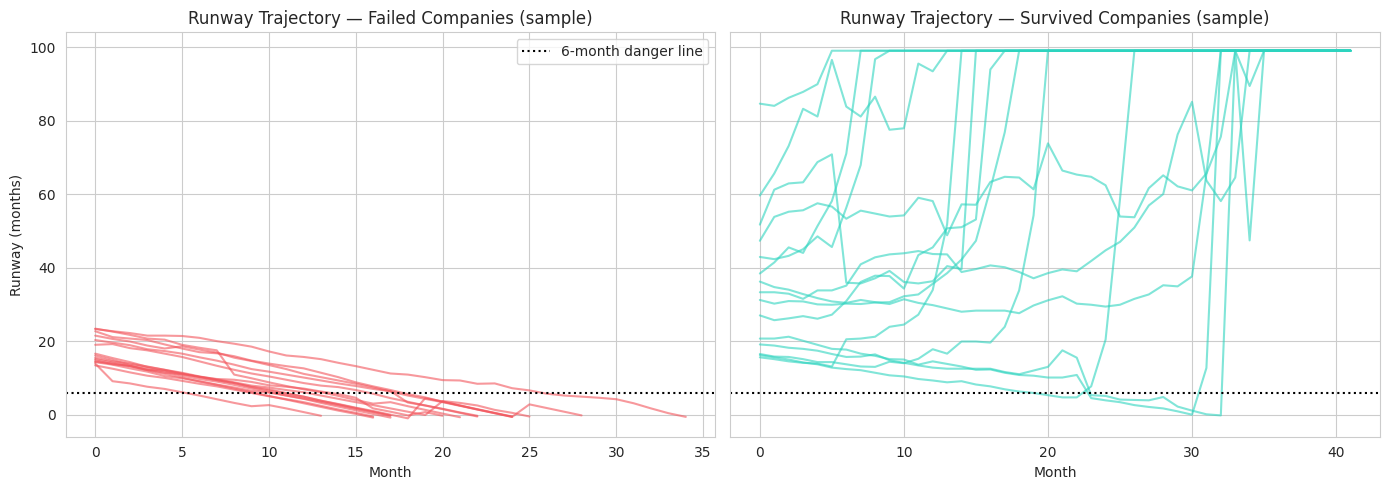

In [5]:
sample_failed = panel[panel['company_id'].isin(
    master[master['failed']]['company_id'].sample(15, random_state=1))]
sample_survived = panel[panel['company_id'].isin(
    master[~master['failed'] & ~master['acquired']]['company_id'].sample(15, random_state=1))]

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
for cid, g in sample_failed.groupby('company_id'):
    axes[0].plot(g['month_index'], g['runway_months'], alpha=0.6, color='#F2545B')
axes[0].set_title('Runway Trajectory — Failed Companies (sample)')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Runway (months)')
axes[0].axhline(6, color='black', linestyle=':', label='6-month danger line')
axes[0].legend()

for cid, g in sample_survived.groupby('company_id'):
    axes[1].plot(g['month_index'], g['runway_months'], alpha=0.6, color='#2DD4BF')
axes[1].set_title('Runway Trajectory — Survived Companies (sample)')
axes[1].set_xlabel('Month')
axes[1].axhline(6, color='black', linestyle=':')
plt.tight_layout()
plt.show()

**Observation:** Failed companies show visibly declining runway trajectories
crossing the 6-month danger line before their failure point, while survivors
mostly stay well above it. This is the core signal the "early warning" framing
is built to detect -- and exactly why `runway_months` and its rolling trend
dominate SHAP importance later in modeling.

## 5. Churn rate vs. failure

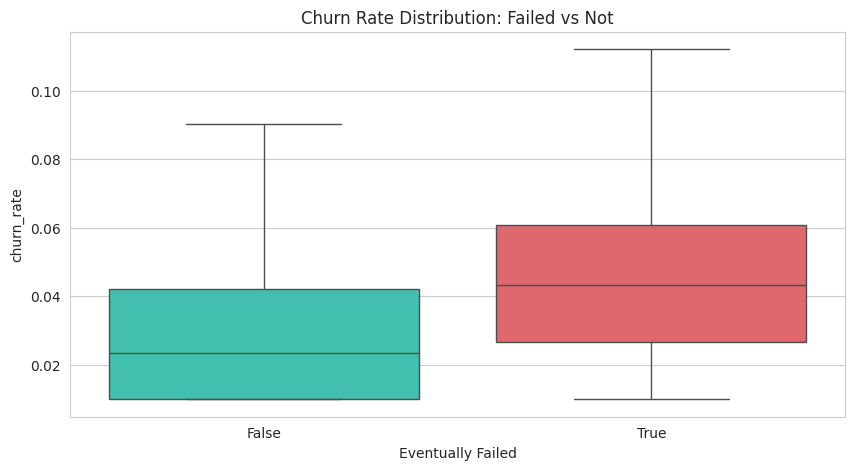

In [6]:
panel_with_outcome = panel.drop(columns=["failed", "fail_month"]).merge(
    master[["company_id","failed"]], on="company_id")
sns.boxplot(data=panel_with_outcome, x="failed", y="churn_rate", showfliers=False,
            hue="failed", palette={True: "#F2545B", False: "#2DD4BF"}, legend=False)
plt.title("Churn Rate Distribution: Failed vs Not")
plt.xlabel("Eventually Failed")
plt.show()

## 6. Correlation among key operating metrics

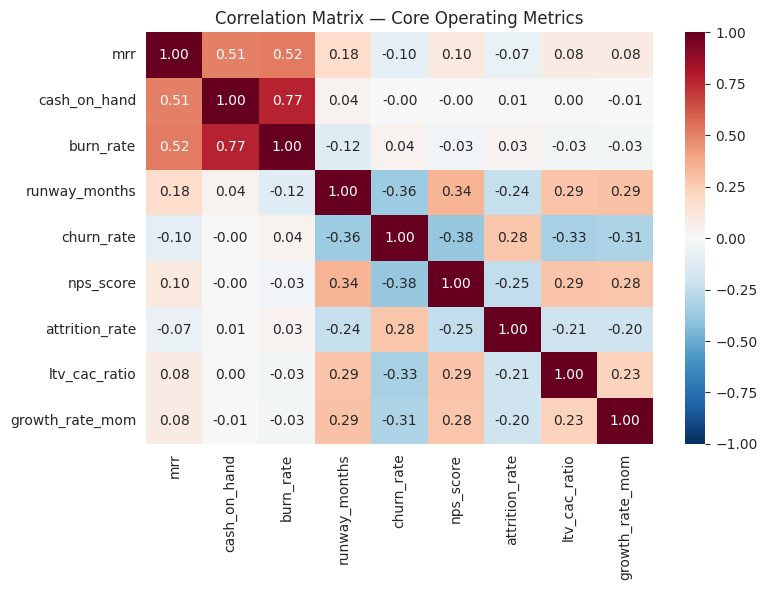

In [7]:
metrics = ['mrr', 'cash_on_hand', 'burn_rate', 'runway_months', 'churn_rate',
           'nps_score', 'attrition_rate', 'ltv_cac_ratio', 'growth_rate_mom']
corr = panel[metrics].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Core Operating Metrics')
plt.tight_layout()
plt.show()

**Observation:** No pair of raw metrics is so highly correlated (|r| > 0.9)
that one is redundant -- each carries distinct signal, which justifies keeping
all of them (plus their trends/volatility) as separate engineered features
rather than collapsing via PCA.

## 7. Class imbalance check (after feature engineering)

label_fail_within_6m
0    0.902266
1    0.097734
Name: proportion, dtype: float64


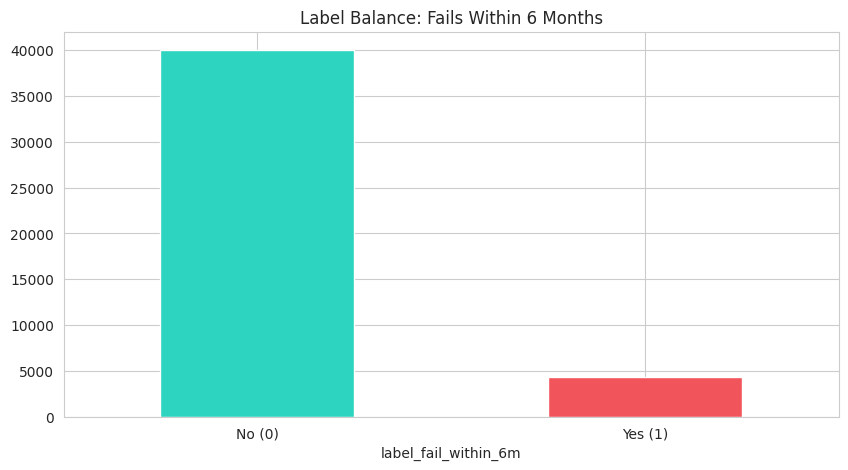

In [8]:
features = pd.read_csv('../data/processed/sfews_features.csv')
print(features['label_fail_within_6m'].value_counts(normalize=True))
features['label_fail_within_6m'].value_counts().plot(kind='bar', color=['#2DD4BF','#F2545B'])
plt.title('Label Balance: Fails Within 6 Months')
plt.xticks([0,1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

**Conclusion:** ~9-10% positive rate confirms meaningful class imbalance.
This rules out plain accuracy as an evaluation metric (predicting "healthy"
for everyone would score ~90%) and motivates `scale_pos_weight` /
`class_weight='balanced'` plus PR-AUC as the primary model-selection metric
in `src/models/train.py`.

**Next notebook/step:** `src/features/build_features.py` for the full
leakage-safe feature engineering pipeline, then `src/models/train.py` for
model comparison and selection.